# Number Recognition by PyTorch (Logistic Regression)

### Preparation

In [13]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import matplotlib.pylab as plt
import numpy as np

torch.manual_seed(0)

function for plotting

In [18]:
def PlotParameters(model):
    W = model.state_dict()['linear.weight'].data
    w_min = W.min().item()
    w_max = W.max().item()
    fig, axes = plt.subplots(2, 5)
    fig.subplots_adjust(hspace=0.01, wspace=0.1)
    for i, ax in enumerate(axes.flat):
        if i < 10:

            # Set the label for the sub-plot.
            ax.set_xlabel("class: {0}".format(i))

            # Plot the image.
            ax.imshow(W[i, :].view(28, 28), vmin=w_min, vmax=w_max, cmap='seismic')

            ax.set_xticks([])
            ax.set_yticks([])

        # Ensure the plot is shown correctly with multiple plots
        # in a single Notebook cell.
    plt.show()

In [19]:
def show_data(data_sample):
    plt.imshow(data_sample[0].numpy().reshape(28, 28), cmap='gray')
    plt.title('y = ' + str(data_sample[1]))

### 1. Data Load and Augment

注意： transform=transforms.ToTensor() 会把图像转为数字

In [14]:
train_dataset = dsets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
print("Print the training dataset:\n ", train_dataset)

Print the training dataset:
  Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()


In [15]:
validation_dataset = dsets.MNIST(root='./data', download=True, transform=transforms.ToTensor())
print("Print the validating dataset:\n ", validation_dataset)

Print the validating dataset:
  Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()


In [16]:
print("Type of data element: ", type(train_dataset[0][1]))

Type of data element:  <class 'int'>


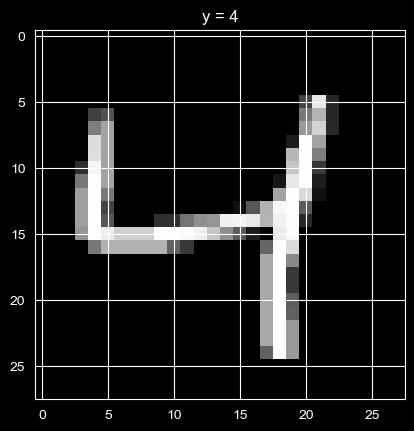

In [20]:
show_data(train_dataset[2])

In [21]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

### 2. Model Definition



In [27]:
class  SoftMax(nn.Module):
    def __init__(self, in_features, out_features):
        super(SoftMax, self).__init__()
        self.linear = nn.Linear(in_features, out_features)
    def forward(self, x):
        return self.linear(x)

In [23]:
input_dim = 28 * 28
output_dim = 10

In [28]:
model = SoftMax(input_dim, output_dim)
print("Print the model:\n ", model)

Print the model:
  SoftMax(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)


- 结果输出10个类别，在模型中就对应有10个线性方程
- 图像为28*28，转成784向量，因此每个线性方程有784个w和1个b

In [34]:
print('W: ',list(model.parameters())[0].size())
print('b: ',list(model.parameters())[1].size())

W:  torch.Size([10, 784])
b:  torch.Size([10])


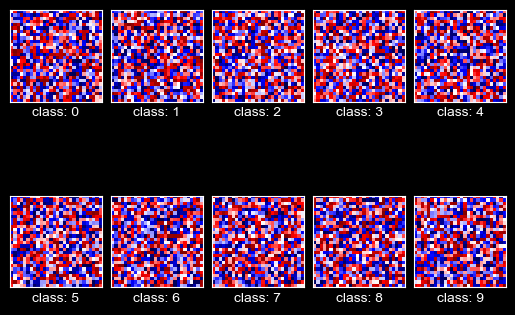

In [35]:
PlotParameters(model)

### 3. Training Configuration

🤔思考： 既然是多分类， 为什么不直接使用softmax而是使用nn.CrossEntropyLoss()
- 核心原因：数学上的“数值稳定性” (Numerical Stability)
- Softmax 函数包含指数运算 $e^{z_k}$。当你的 Logits（线性层输出的 $z$）非常大时，$e^{z}$ 会迅速爆炸，导致计算机内存溢出（Overflow）。
- nn.CrossEntropyLoss() 的黑科技：它在内部将 LogSoftmax 和 NLLLoss（负对数似然损失）合并了。
- Log-Sum-Exp 技巧：它使用了一种数学上的技巧，直接计算 $\log(\text{Softmax})$，从而避免了中间步骤出现巨大的指数值。这保证了模型训练时不会因为数值太大而崩溃。

数学上，nn.CrossEntropyLoss() 等同于以下两个步骤的组合：
1. LogSoftmax: 先对输入的原始得分（Logits）进行 Softmax，然后再取对数 $\log$。
2. NLLLoss (Negative Log Likelihood Loss): 负对数似然损失，用来衡量预测概率分布与真实标签之间的差距。$$\text{CrossEntropyLoss} = \text{LogSoftmax} + \text{NLLLoss}$$

In [38]:
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=100)
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=5000)

### 4. Training Loop

#### Flatten Input Images to 1D vectors
思考： 为什么使用x.view(-1, 28*28) 将图像转1D向量

In [39]:
n_epochs = 10
loss_list = []
accuracy_list = []
N_test = len(validation_dataset)
N_train = len(train_dataset)

def train_model(n_epochs):
    for epoch in range(n_epochs):
        for epoch in range(n_epochs):
            model.train() # 明确设置为训练模式
            total_loss = 0
            for x, y in train_loader:
                optimizer.zero_grad()
                output = model(x.view(-1, 28 * 28))
                loss = criterion(output, y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            correct = 0
            model.eval()
            with torch.no_grad(): # 省内在
                for xt, yt in validation_dataset:
                    z = model(xt.view(-1, 28 * 28))
                    _, yhat = torch.max(z.data, 1)
                    correct += (yt == yhat).sum().item()
            accuracy = correct/N_test
            loss_list.append(total_loss/N_train)
            accuracy_list.append(accuracy)

In [40]:
train_model(n_epochs)

### 5. Model Evaluation

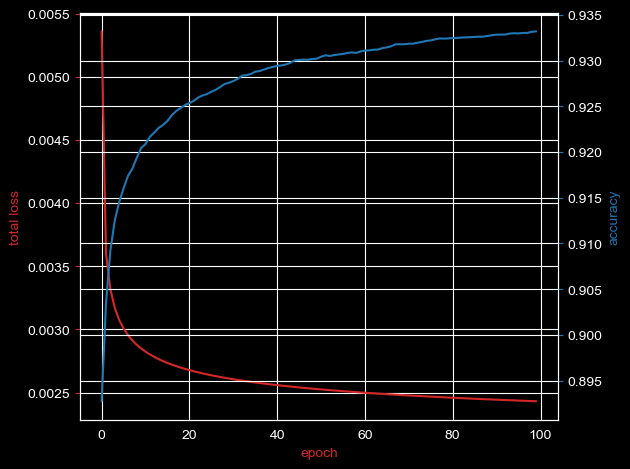

In [41]:
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.plot(loss_list,color=color)
ax1.set_xlabel('epoch',color=color)
ax1.set_ylabel('total loss',color=color)
ax1.tick_params(axis='y', color=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('accuracy', color=color)
ax2.plot( accuracy_list, color=color)
ax2.tick_params(axis='y', color=color)
fig.tight_layout()

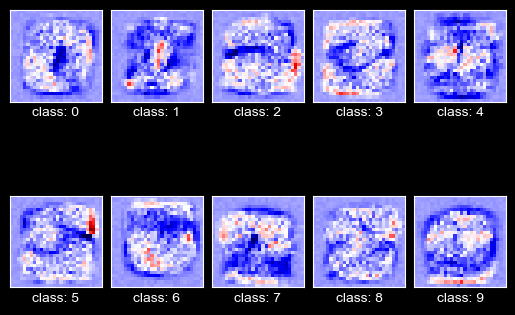

In [42]:
PlotParameters(model)

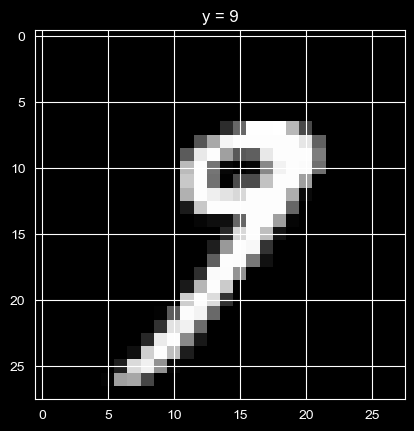

yhat: tensor([7])
probability of class  0.5091023445129395


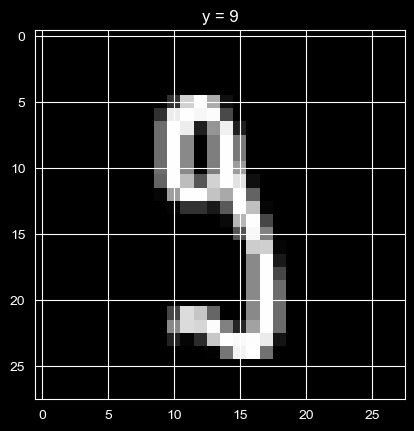

yhat: tensor([5])
probability of class  0.7173197865486145


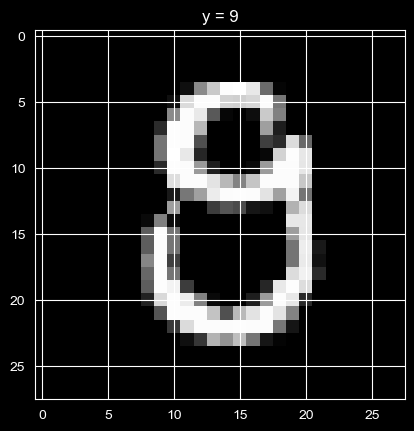

yhat: tensor([8])
probability of class  0.5812511444091797


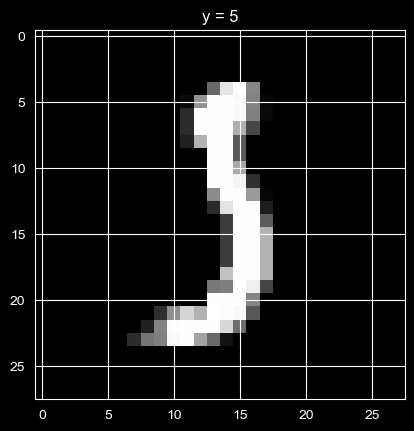

yhat: tensor([3])
probability of class  0.7819907069206238


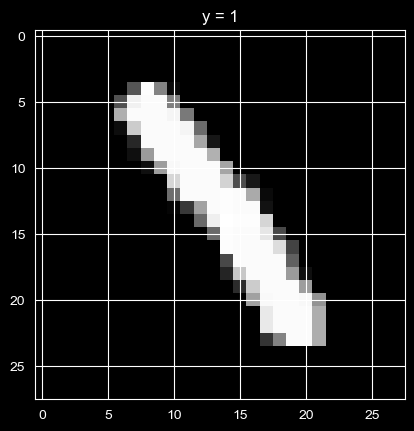

yhat: tensor([3])
probability of class  0.5044074654579163


In [43]:
# Plot the misclassified samples
Softmax_fn=nn.Softmax(dim=-1)
count = 0
for x, y in validation_dataset:
    z = model(x.reshape(-1, 28 * 28))
    _, yhat = torch.max(z, 1)
    if yhat != y:
        show_data((x, y))
        plt.show()
        print("yhat:", yhat)
        print("probability of class ", torch.max(Softmax_fn(z)).item())
        count += 1
    if count >= 5:
        break

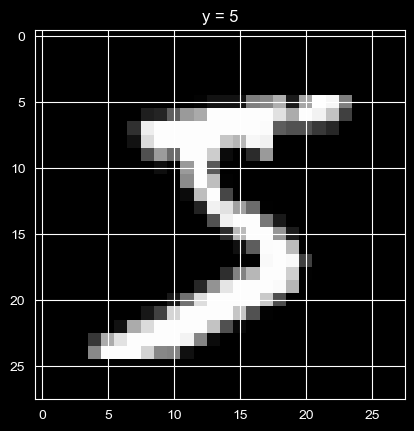

yhat: tensor([5])
probability of class  0.8447673916816711


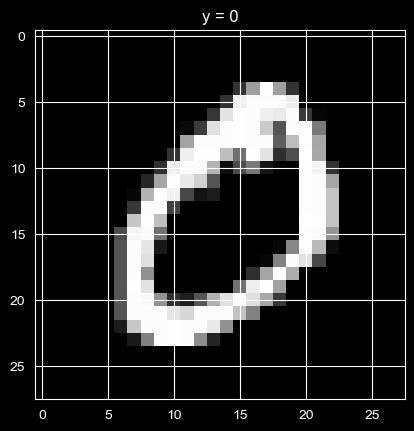

yhat: tensor([0])
probability of class  0.9999701976776123


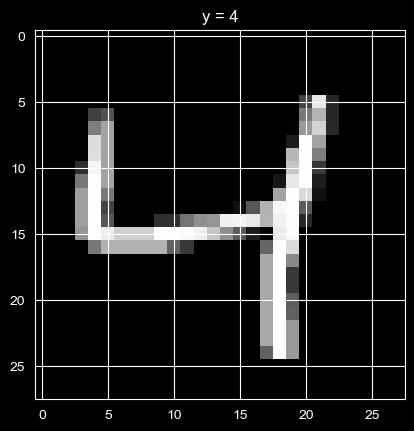

yhat: tensor([4])
probability of class  0.758898138999939


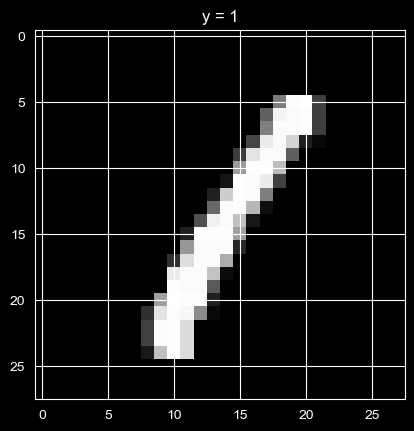

yhat: tensor([1])
probability of class  0.9732701778411865


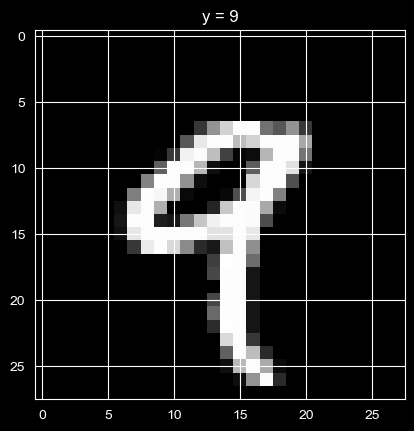

yhat: tensor([9])
probability of class  0.9582628607749939


In [44]:
# Plot the classified samples
Softmax_fn=nn.Softmax(dim=-1)
count = 0
for x, y in validation_dataset:
    z = model(x.reshape(-1, 28 * 28))
    _, yhat = torch.max(z, 1)
    if yhat == y:
        show_data((x, y))
        plt.show()
        print("yhat:", yhat)
        print("probability of class ", torch.max(Softmax_fn(z)).item())
        count += 1
    if count >= 5:
        break

# ShallowNN
![](https://s3.engcard.dpdns.org/images/ai/image1231414dsfaa.png)
1 hidden layer , 2 neurons

In [1]:

import torch
import torch.nn as nn
from torch import sigmoid
import matplotlib.pylab as plt
import numpy as np
torch.manual_seed(0)

In [2]:
def PlotStuff(X, Y, model, epoch, leg=True):

    plt.plot(X.numpy(), model(X).detach().numpy(), label=('epoch ' + str(epoch)))
    plt.plot(X.numpy(), Y.numpy(), 'r')
    plt.xlabel('x')
    if leg == True:
        plt.legend()
    else:
        pass

In [3]:
class ShallowNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ShallowNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.a1 = None
        self.l1 = None
        self.l2=None
    def forward(self, x):
        self.l1 = self.fc1(x)
        self.a1 = sigmoid(self.l1)
        self.l2 = self.fc2(self.a1)
        yhat = sigmoid(self.l2)
        return yhat

In [14]:
def train(Y, X, model, optimizer, criterion, epochs=1000):
    cost = []
    total=0
    for epoch in range(epochs):
        total=0
        for y, x in zip(Y, X):
            yhat = model(x)
            loss = criterion(yhat, y.view(1))
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            #cumulative loss
            total+=loss.item()
        cost.append(total)
        if epoch % 300 == 0:
            PlotStuff(X, Y, model, epoch, leg=True)
            plt.show()
            model(X)
            plt.scatter(model.a1.detach().numpy()[:, 0], model.a1.detach().numpy()[:, 1], c=Y.numpy().reshape(-1))
            plt.title('activations')
            plt.show()
    return cost

Make some data

In [5]:
X = torch.arange(-20, 20, 1).view(-1, 1).type(torch.FloatTensor)
Y = torch.zeros(X.shape[0])
Y[(X[:, 0] > -4) & (X[:, 0] < 4)] = 1.0

Loss Function

In [6]:
def criterion_cross(outputs, labels):
    out = -1 * torch.mean(labels * torch.log(outputs) + (1 - labels) * torch.log(1 - outputs))
    return out

Config model

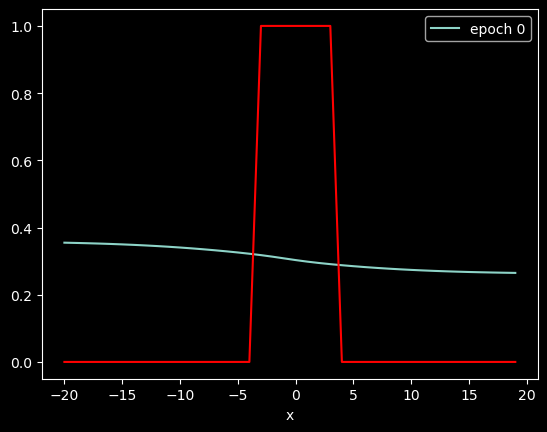

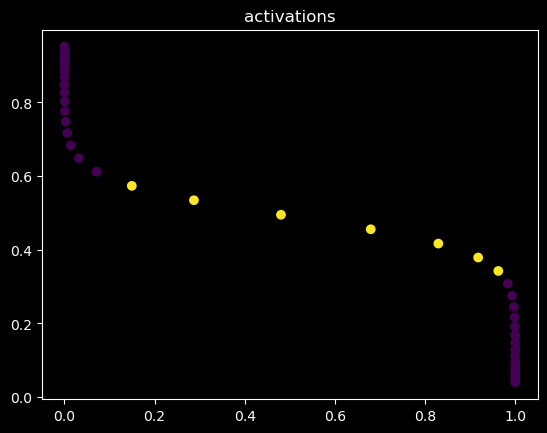

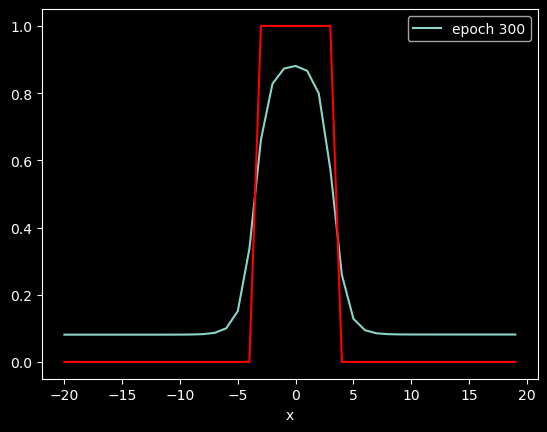

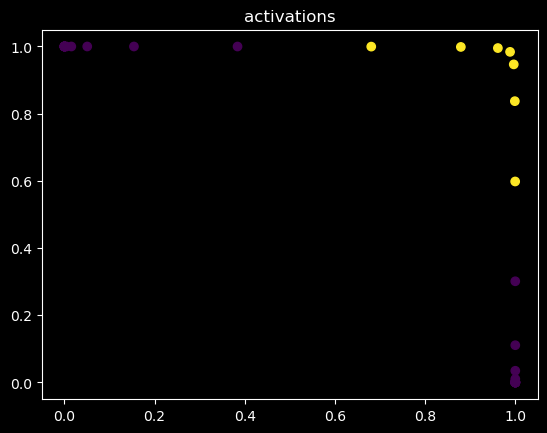

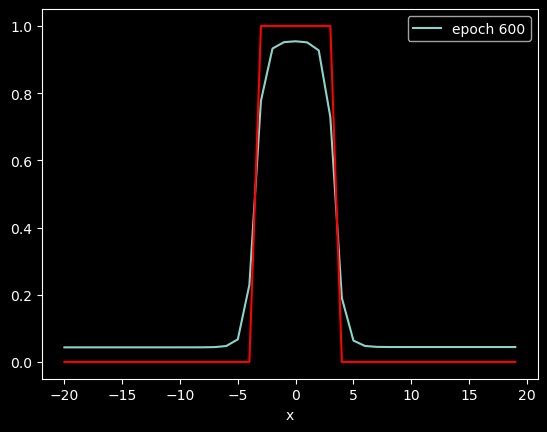

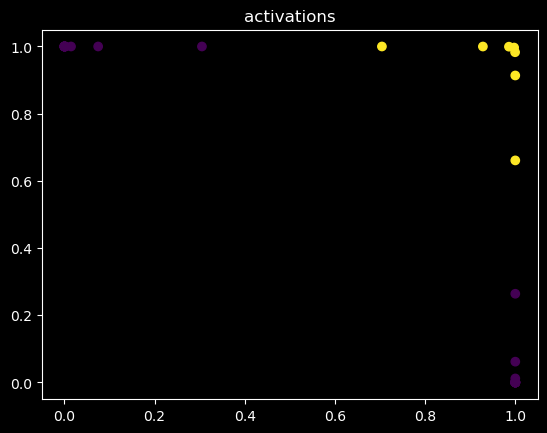

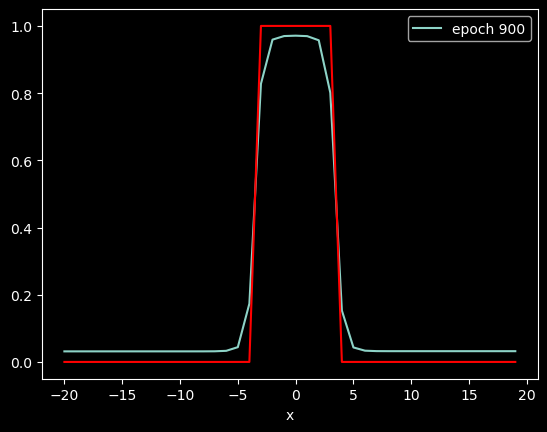

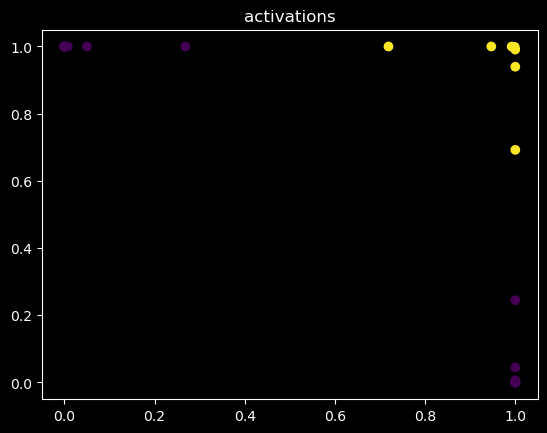

Text(0.5, 1.0, 'cross entropy loss')

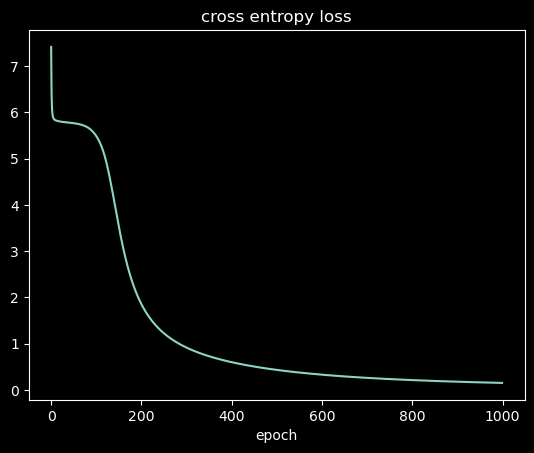

In [15]:
# Train the model
# size of input
D_in = 1
# size of hidden layer
H = 2
# number of outputs
D_out = 1
# learning rate
learning_rate = 0.1
# create the model
model = ShallowNN(D_in, H, D_out)
#optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
#train the model usein
# criterion = criterion_cross
criterion = torch.nn.MSELoss()
cost_cross = train(Y, X, model, optimizer, criterion, epochs=1000)
#plot the loss
plt.plot(cost_cross)
plt.xlabel('epoch')
plt.title('cross entropy loss')

Make a Prediction

In [9]:
x=torch.tensor([0.0])
yhat=model(x)
yhat

tensor([0.9969], grad_fn=<SigmoidBackward0>)

# More Hidden Neurons

![](https://s3.engcard.dpdns.org/images/ai/WX20260220-184411@2x.png)

Make data

In [16]:
from torch.utils.data import Dataset, DataLoader

In [17]:
class Data(Dataset):
    def __init__(self):
        self.x=torch.linspace(-20, 20, 100).view(-1,1)

        self.y=torch.zeros(self.x.shape[0])
        self.y[(self.x[:,0]>-10)& (self.x[:,0]<-5)]=1
        self.y[(self.x[:,0]>5)& (self.x[:,0]<10)]=1
        self.y=self.y.view(-1,1)
        self.len=self.x.shape[0]
    def __getitem__(self,index):

        return self.x[index],self.y[index]
    def __len__(self):
        return self.len

In [22]:
def get_hist(model,data_set):
    activations=model.activation(data_set.x)
    for i,activation in enumerate(activations):
        plt.hist(activation.numpy(),4,density=True)
        plt.title("Activation layer " + str(i+1))
        plt.xlabel("Activation")
        plt.xlabel("Activation")
        plt.legend()
        plt.show()

In [23]:
def PlotStuff(X, Y, model=None, leg=False):
    plt.plot(X[Y == 0].numpy(), Y[Y == 0].numpy(), 'or', label='training points y=0 ')
    plt.plot(X[Y == 1].numpy(), Y[Y == 1].numpy(), 'ob', label='training points y=1 ')

    if model != None:
        plt.plot(X.numpy(), model(X).detach().numpy(), label='neral network ')
    plt.legend()
    plt.show();

In [24]:
 def train(data_set,model,criterion, train_loader, optimizer, epochs=5,plot_number=10):
    cost=[]

    for epoch in range(epochs):
        total=0

        for x,y in train_loader:
            optimizer.zero_grad()

            yhat=model(x)
            loss=criterion(yhat,y)
            loss.backward()
            optimizer.step()
            total+=loss.item()

        if epoch%plot_number==0:
            PlotStuff(data_set.x,data_set.y,model)

        cost.append(total)
    plt.figure()
    plt.plot(cost)
    plt.xlabel('epoch')
    plt.ylabel('cost')
    plt.show()
    return cost

In [25]:
data_set=Data()

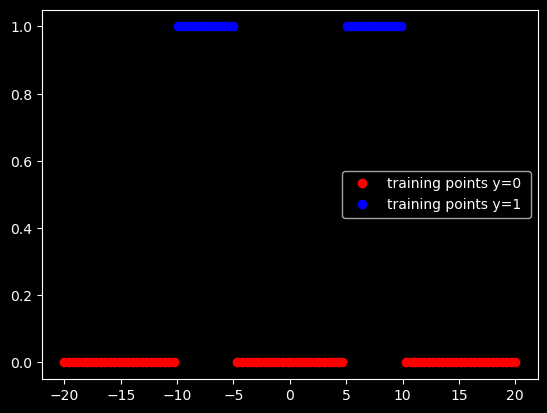

In [26]:
PlotStuff(data_set.x,data_set.y,leg=False)

注意隐藏层使用9个神经元

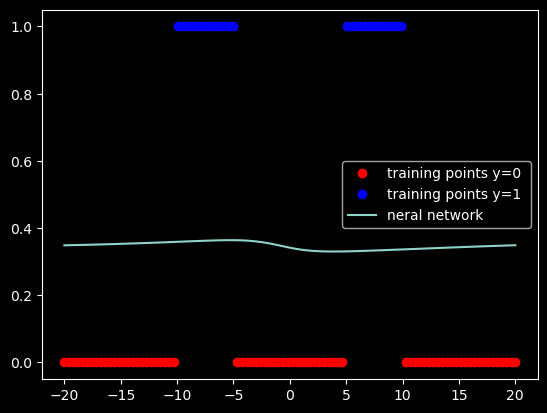

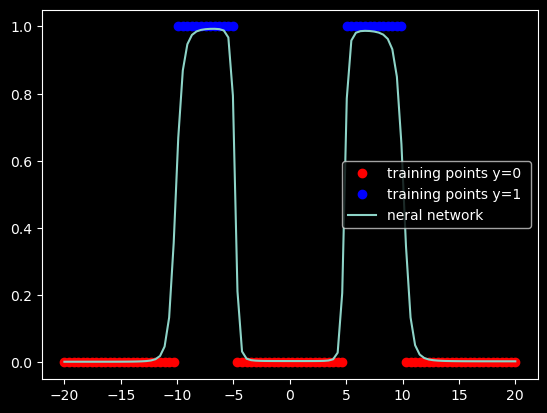

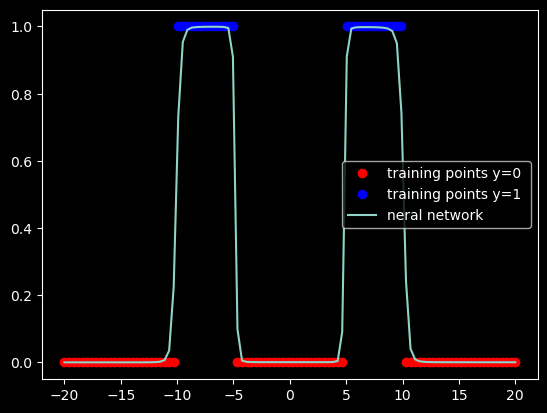

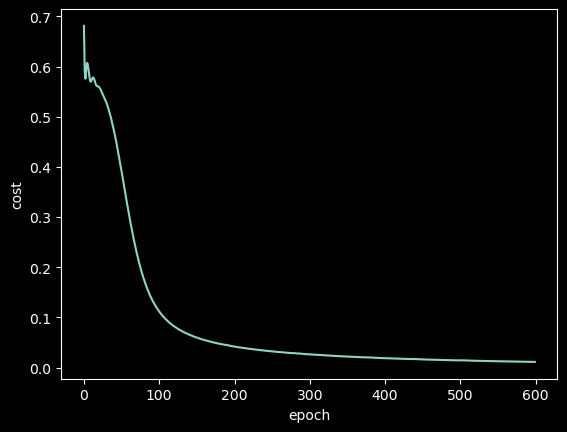

In [27]:
torch.manual_seed(0)
model=ShallowNN(1,9,1)
learning_rate=0.1
criterion=nn.BCELoss()
optimizer=torch.optim.Adam(model.parameters(), lr=learning_rate)
train_loader=DataLoader(dataset=data_set,batch_size=100)
COST=train(data_set,model,criterion, train_loader, optimizer, epochs=600,plot_number=200)

使用nn.Sequentail 创建model

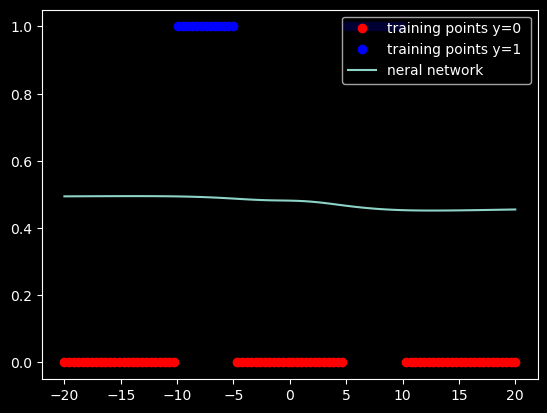

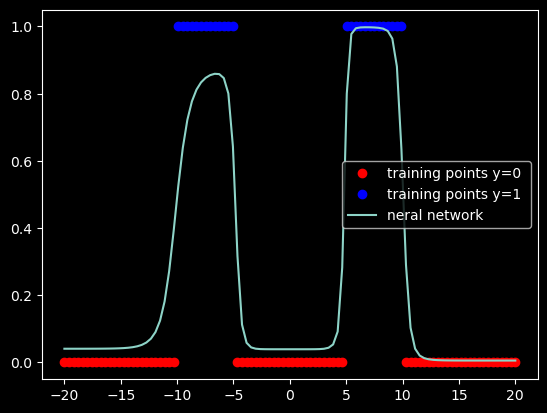

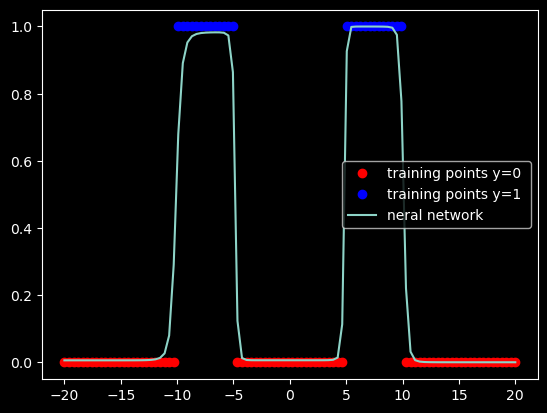

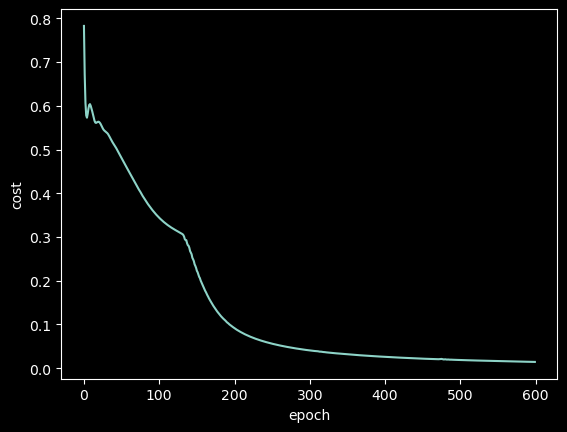

In [30]:
model_6neurons= torch.nn.Sequential(
    torch.nn.Linear(1, 6),
    torch.nn.Sigmoid(),
    torch.nn.Linear(6,1),
    torch.nn.Sigmoid()
)

optimizer_6 = torch.optim.Adam(model_6neurons.parameters(), lr=learning_rate) # 注意优化器是有状态的， 而loss函数是一个函数，无状态。
COST=train(data_set,model_6neurons,criterion, train_loader, optimizer_6, epochs=600,plot_number=200)

# Multi Dimension input

![](https://s3.engcard.dpdns.org/images/ai/WX20260220-190051@2x.png)

![](https://s3.engcard.dpdns.org/images/ai/dimentionality-expansion.png)

In [31]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from torch.utils.data import Dataset, DataLoader

In [32]:
def plot_decision_regions_2class(model,data_set):
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#00AAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#00AAFF'])
    X = data_set.x.numpy()
    y = data_set.y.numpy()
    h = .02
    x_min, x_max = X[:, 0].min() - 0.1 , X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1 , X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),np.arange(y_min, y_max, h))
    XX = torch.Tensor(np.c_[xx.ravel(), yy.ravel()])

    yhat = np.logical_not((model(XX)[:, 0] > 0.5).numpy()).reshape(xx.shape)
    plt.pcolormesh(xx, yy, yhat, cmap=cmap_light)
    plt.plot(X[y[:, 0] == 0, 0], X[y[:, 0] == 0, 1], 'o', label='y=0')
    plt.plot(X[y[:, 0] == 1, 0], X[y[:, 0] == 1, 1], 'ro', label='y=1')
    plt.title("decision region")
    plt.legend()

In [33]:

def accuracy(model, data_set):
    return np.mean(data_set.y.view(-1).numpy() == (model(data_set.x)[:, 0] > 0.5).numpy())

In [34]:
class MdNet(nn.Module):
    # Constructor
    def __init__(self, D_in, H, D_out):
        super(MdNet, self).__init__()
        #hidden layer
        self.linear1 = nn.Linear(D_in, H)
        #output layer
        self.linear2 = nn.Linear(H, D_out)

    # Prediction
    def forward(self, x):
        x = torch.sigmoid(self.linear1(x))
        x = torch.sigmoid(self.linear2(x))
        return x

In [35]:

def train(data_set, model, criterion, train_loader, optimizer, epochs=5):
    COST = []
    ACC = []
    for epoch in range(epochs):
        total=0
        for x, y in train_loader:
            optimizer.zero_grad()
            yhat = model(x)
            loss = criterion(yhat, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            #cumulative loss
            total+=loss.item()
        ACC.append(accuracy(model, data_set))
        COST.append(total)

    fig, ax1 = plt.subplots()
    color = 'tab:red'
    ax1.plot(COST, color=color)
    ax1.set_xlabel('epoch', color=color)
    ax1.set_ylabel('total loss', color=color)
    ax1.tick_params(axis='y', color=color)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('accuracy', color=color)  # we already handled the x-label with ax1
    ax2.plot(ACC, color=color)
    ax2.tick_params(axis='y', color=color)
    fig.tight_layout()  # otherwise the right y-label is slightly clipped

    plt.show()

    return COST

In [37]:
class XOR_Data(Dataset):

    # Constructor
    def __init__(self, N_s=100):
        self.x = torch.zeros((N_s, 2))
        self.y = torch.zeros((N_s, 1))
        for i in range(N_s // 4):
            self.x[i, :] = torch.Tensor([0.0, 0.0])
            self.y[i, 0] = torch.Tensor([0.0])

            self.x[i + N_s // 4, :] = torch.Tensor([0.0, 1.0])
            self.y[i + N_s // 4, 0] = torch.Tensor([1.0])

            self.x[i + N_s // 2, :] = torch.Tensor([1.0, 0.0])
            self.y[i + N_s // 2, 0] = torch.Tensor([1.0])

            self.x[i + 3 * N_s // 4, :] = torch.Tensor([1.0, 1.0])
            self.y[i + 3 * N_s // 4, 0] = torch.Tensor([0.0])

            self.x = self.x + 0.01 * torch.randn((N_s, 2))
        self.len = N_s

    # Getter
    def __getitem__(self, index):
        return self.x[index],self.y[index]

    # Get Length
    def __len__(self):
        return self.len

    # Plot the data
    def plot_stuff(self):
        plt.plot(self.x[self.y[:, 0] == 0, 0].numpy(), self.x[self.y[:, 0] == 0, 1].numpy(), 'o', label="y=0")
        plt.plot(self.x[self.y[:, 0] == 1, 0].numpy(), self.x[self.y[:, 0] == 1, 1].numpy(), 'ro', label="y=1")
        plt.legend()

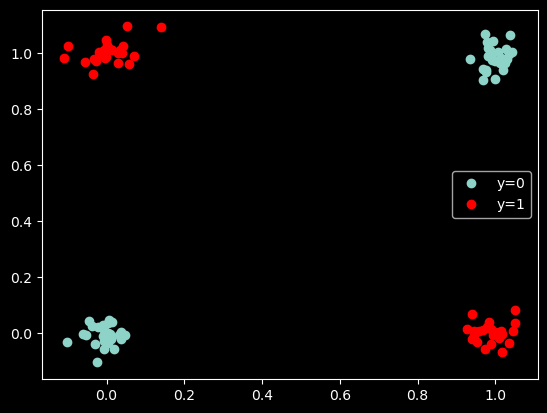

In [38]:
data_set = XOR_Data()
data_set.plot_stuff()

### one neuron

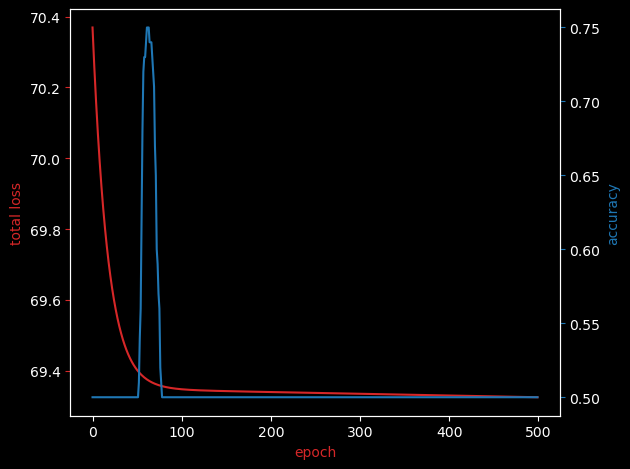

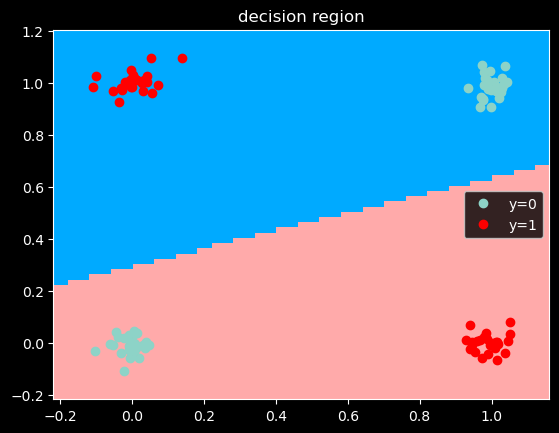

In [41]:
model = MdNet(2,1,1)
learning_rate = 0.001
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train_loader = DataLoader(dataset=data_set, batch_size=1)
LOSS12 = train(data_set, model, criterion, train_loader, optimizer, epochs=500)
plot_decision_regions_2class(model, data_set)

### 2 neurons

In [43]:
model = MdNet(2,2,1)

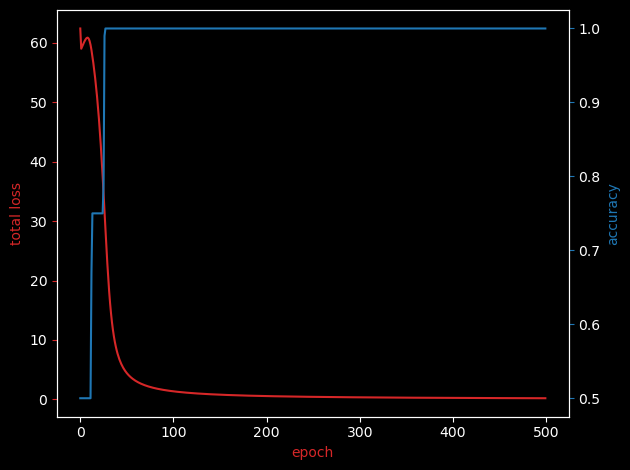

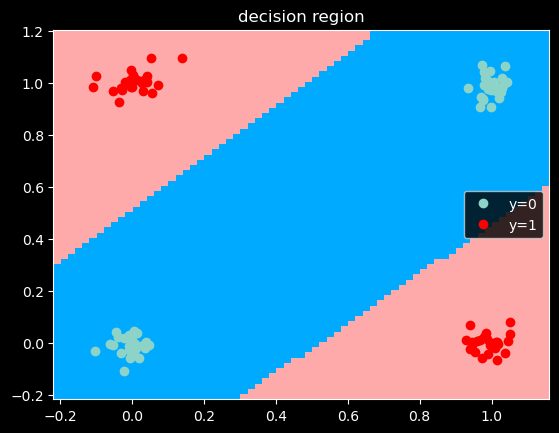

In [44]:
learning_rate = 0.1
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train_loader = DataLoader(dataset=data_set, batch_size=1)
LOSS12 = train(data_set, model, criterion, train_loader, optimizer, epochs=500)
plot_decision_regions_2class(model, data_set)

## 3 neurons

In [45]:
model = MdNet(2,3,1)

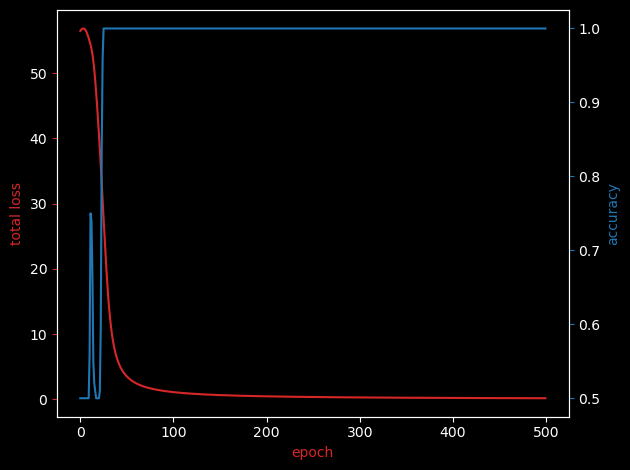

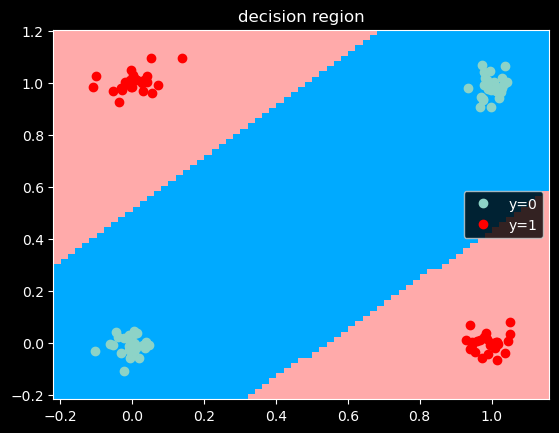

In [46]:
learning_rate = 0.1
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train_loader = DataLoader(dataset=data_set, batch_size=1)
LOSS12 = train(data_set, model, criterion, train_loader, optimizer, epochs=500)
plot_decision_regions_2class(model, data_set)

思考：为什么三个神经元 没有画出3条线？
 奥卡姆剃刀”现象：
- 数据需求：你的 XOR 数据集（红点在对角线）逻辑上只需要两条平行线就能包抄。
- 模型适应：当你给模型 3 个神经元时，模型发现用 2 个神经元就能把 Loss 降到最低了。
- 第三个神经元的去向：
    - 被推向“荒野”：b偏置被设置地非常大，被移动到了远离数据点的“荒野”区域
    - 权重归零：其输出权重被调得很低，导致它在图中“隐身”了。
    - 影子神经元：第三条线可能和第一条或第二条线完全重合了

---

# Multi-Class Neural Network

思考： 已知有10个分类， 每个神经元会负责拟合某一个分类吗？也就说整个DNN里所有神经元会按分类规划吗？

**输出层**和**隐藏层**的逻辑是完全不同的：
- **隐藏层（那 16 个神经元）**：它们确实**不需要**关注分类。它们是“特征提取器”。有的神经元可能在学习识别“圆圈”，有的在学习识别“交叉线”。它们的权重是随机初始化的，在训练过程中，它们会自动分工，提取出对分类最有用的特征。

- **输出层（那 10 个神经元）**：它们**必须**与分类对应。虽然初始化是随机的，但**标签（Label）**赋予了它们具体的物理意义。
    - 比如你的标签 y=3，在计算 Loss 时，系统会强迫**第 4 个输出神经元**（索引为 3）的数值变大，而让其他 9 个变小。

    - **结论**：神经元并不是“天生”负责某个类，而是因为你给它的训练数据中，第 i 个位置代表了第 i 类，它才被“训练”成了那个类的代言人。

思考：为什么隐藏层没有规划神经元分类训练，而输出层能预测分类？

**隐藏层：特征“提纯” (Feature Extraction)**
-  **动作**：将杂乱的原始输入（如像素点）映射到一个更高维的特征空间。
-  **结果**：同一类别的样本在通过隐藏层后，会产生**高度相似**的激活值向量；而不同类别的样本则会被**拉开距离**。

**输出层：线性“打分” (Logits Calculation)**
- **动作**：输出层的 10 个神经元分别持有 10 组针对这些特征的“过滤器”（权重参数 $W$）。
- **结果**：当隐藏层输出的“数字 3 的特征”经过时，**第 4 个神经元**（索引 3）匹配度最高，计算出的得分（Logit）远超其他神经元。

**Softmax：归一化“概率” (Probability Mapping)**
- **动作**：将这 10 个悬殊的得分进行指数化和归一化。
- **结果**：得分最高的神经元被转化为接近 **1** 的概率，其他神经元被压低至接近 **0**，从而实现对样本的分类预测。

In [17]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import torch.nn.functional as F
import matplotlib.pylab as plt
import numpy as np

In [18]:

def plot_accuracy_loss(training_results):
    plt.subplot(2, 1, 1)
    plt.plot(training_results['training_loss'], 'r')
    plt.ylabel('loss')
    plt.title('training loss iterations')
    plt.subplot(2, 1, 2)
    plt.plot(training_results['validation_accuracy'])
    plt.ylabel('accuracy')
    plt.xlabel('epochs')
    plt.show()

In [19]:
def print_model_parameters(model):
    count = 0
    for ele in model.state_dict():
        count += 1
        if count % 2 != 0:
            print ("The following are the parameters for the layer ", count // 2 + 1)
        if ele.find("bias") != -1:
            print("The size of bias: ", model.state_dict()[ele].size())
        else:
            print("The size of weights: ", model.state_dict()[ele].size())

In [20]:
def show_data(data_sample):
    plt.imshow(data_sample.numpy().reshape(28, 28), cmap='gray')
    plt.show()

In [23]:
class Net(nn.Module):
    # Constructor
    def __init__(self, D_in, H, D_out):
        super(Net, self).__init__()
        self.linear1 = nn.Linear(D_in, H)
        self.linear2 = nn.Linear(H, D_out)

    # Prediction
    def forward(self, x):
        x = torch.sigmoid(self.linear1(x))
        x = self.linear2(x)
        return x

思考：为什么第二层没有激活函数？
- 第二层是输出层，输出层使用softmax作为多分类的激活函数，
- 在pytorch中往往使用nn.CrossEntropyLoss 这个损失函数， 它同时包含了softmax充当了输出层激活函数

In [24]:
def train(model, criterion, train_loader, validation_loader, optimizer, epochs=100):
    i = 0
    useful_stuff = {'training_loss': [],'validation_accuracy': []}
    for epoch in range(epochs):
        for i, (x, y) in enumerate(train_loader):
            optimizer.zero_grad()
            z = model(x.view(-1, 28 * 28))
            loss = criterion(z, y)
            loss.backward()
            optimizer.step()
             #loss for every iteration
            useful_stuff['training_loss'].append(loss.data.item())
        correct = 0
        for x, y in validation_loader:
            #validation
            z = model(x.view(-1, 28 * 28))
            _, label = torch.max(z, 1)
            correct += (label == y).sum().item()
        accuracy = 100 * (correct / len(validation_dataset))
        useful_stuff['validation_accuracy'].append(accuracy)
    return useful_stuff

In [25]:
train_dataset = dsets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())

In [26]:
validation_dataset = dsets.MNIST(root='./data', download=True, transform=transforms.ToTensor())

In [27]:
criterion = nn.CrossEntropyLoss()
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=2000, shuffle=True)
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=5000, shuffle=False)

In [28]:
input_dim = 28 * 28
hidden_dim = 100
output_dim = 10

model = Net(input_dim, hidden_dim, output_dim)

In [12]:
print_model_parameters(model)

The following are the parameters for the layer  1
The size of weights:  torch.Size([100, 784])
The size of bias:  torch.Size([100])
The following are the parameters for the layer  2
The size of weights:  torch.Size([10, 100])
The size of bias:  torch.Size([10])


In [30]:
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [14]:
training_results = train(model, criterion, train_loader, validation_loader, optimizer, epochs=30)

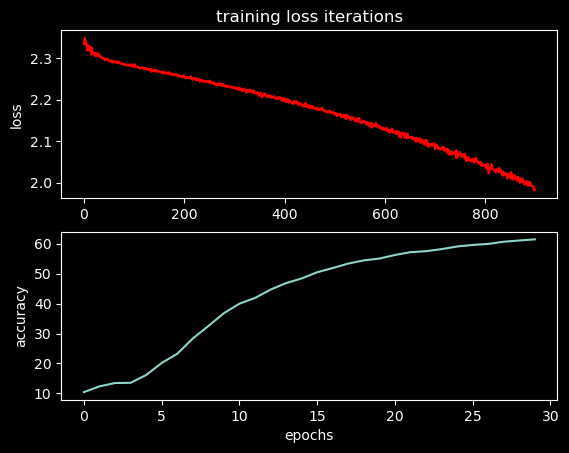

In [15]:
plot_accuracy_loss(training_results)

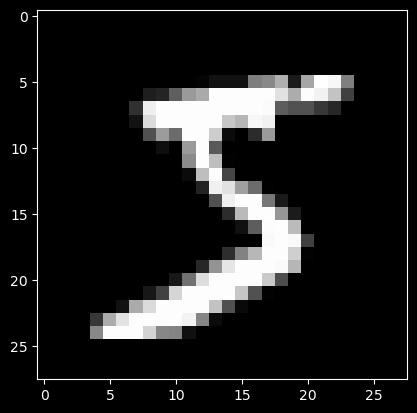

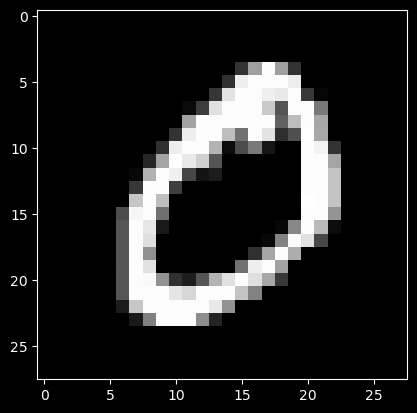

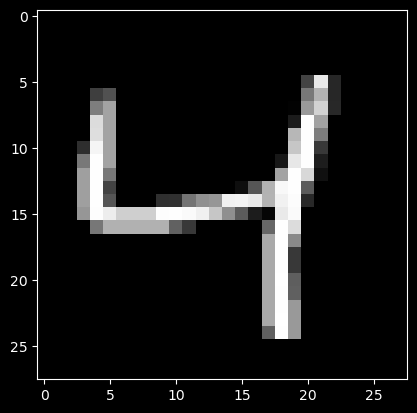

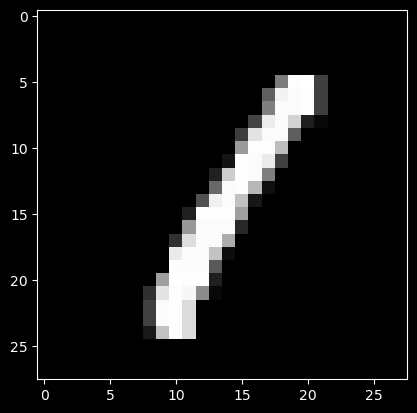

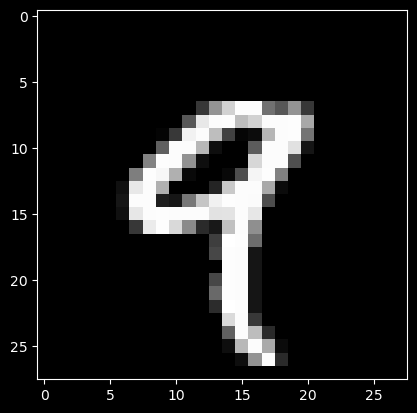

In [31]:
# Plot the first five misclassified samples

count = 0
for x, y in validation_dataset:
    z = model(x.reshape(-1, 28 * 28))
    _,yhat = torch.max(z, 1)
    if yhat != y:
        show_data(x)
        count += 1
    if count >= 5:
        break

练习：使用nn.Sequential来定义model

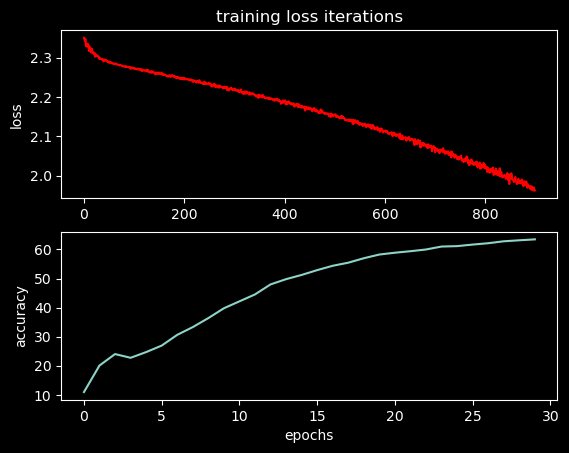

In [33]:
model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim), # 第一步：把 784 映射到 100个隐藏层神经元
    nn.Sigmoid(), # 应用隐藏层神经元
    nn.Linear(hidden_dim, output_dim),
)
optimizer_1 = torch.optim.SGD(model.parameters(), lr=learning_rate)
training_results = train(model, criterion, train_loader, validation_loader, optimizer_1, epochs=30)
plot_accuracy_loss(training_results)